<center><font size=6>Personal Loan Campaign Project - Karan</font></center>

<center><img src="https://plus.unsplash.com/premium_photo-1770480428149-ff0aad75ad33?q=80&w=1405&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D" width="1080"></center>

# **Problem Statement**

## **Business Context**

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

## **Objectives**

As a Data Scientist at AllLife Bank have to build a model that will help-
- The marketing department to identify the potential customers who have a higher probability of purchasing the loan
- To predict whether a liability customer will buy personal loans
- To identify which segment of customers to target more.

## **Data Dictionary**

1. `ID`: Customer ID
2. `Age`: Customer's age in completed years
3. `Experience`: # years of professional experience
4. `Income`: Annual income of the customer (in thousand dollars)
5. `ZIP Code`: Home Address ZIP code.
6. `Family`: The family size of the customer
7. `CCAvg`: Average spending on credit cards per month (in thousand dollars)
8. `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
9. `Mortgage`: Value of house mortgage if any. (in thousand dollars)
10. `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign?
11. `Securities_Account`: Does the customer have a securities account with the bank?
12. `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank?
13. `Online`: Do customers use Internet banking facilities?
14. `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All Life Bank)?

# **Importing the necessary libraries**

In [ ]:
# to load and manipulate data
import pandas as pd
import numpy as np

# to visualize data
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# to split the data into train and test sets
from sklearn.model_selection import train_test_split

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# to build a linear regression model
from sklearn.linear_model import LinearRegression

# to check a regression model's performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# to build decision tree model
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# to tune different models
from sklearn.model_selection import GridSearchCV

# to compute classification metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
)

In [ ]:
# Libraries for scaling numerical features
from sklearn.preprocessing import StandardScaler

# to perform k-means clustering
from sklearn.cluster import KMeans

# to perform silhouette analysis
from sklearn.metrics import silhouette_score

# to perform t-SNE
from sklearn.manifold import TSNE

# to define a common seed value to be used throughout
RS=0

# **Loading the data**

In [ ]:
# loading data into a pandas dataframe
Loan = pd.read_csv("Loan_Modelling.csv")

In [ ]:
# creating a copy of the data
data = Loan.copy()

# **Data Overview**

### Viewing the first and last 5 rows of the dataset

In [ ]:
data.head(5)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [ ]:
data.tail(5)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


### Checking the shape of the dataset.

In [ ]:
data.shape

(5000, 14)

* The dataset has 5000 rows and 14 columns.

## **Checking the attribute types**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


- There are 6 numerical and 8 categorical variables in the data.
- Family, CCAvg, Education, Mortgage, Personal_Loan, Securities_Account, CD_Account	Online and CreditCard, although interpreted here as numerical, are categorical variables that are encoded by default.
- There are no null values in the data.

### Checking the statistical summary

In [ ]:
data.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


- On average, customers have an annual household income of ~$74k.
- The age of the customers ranges from 22 to 67 years.

### Checking for missing values

In [ ]:
# checking for null values
data.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


- There are no missing values in the data.

### Checking for duplicate values

In [ ]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

### Checking the unique value counts

In [ ]:
data.nunique()

,0
ID,5000
Age,45
Experience,47
Income,162
ZIPCode,467
Family,4
CCAvg,108
Education,3
Mortgage,347
Personal_Loan,2


### Remove Unnecessary column

In [ ]:
#Remove ID column
data = data.drop(columns=['ID']) # ID columns dosen't help in ML Model
print("\nData Shape after removing ID column:", data.shape)


Data Shape after removing ID column: (5000, 13)


# **Data Preprocessing**

### Checking for Anomalous Values

In [ ]:
data["Experience"].unique()

array([ 1, 19, 15,  9,  8, 13, 27, 24, 10, 39,  5, 23, 32, 41, 30, 14, 18,
       21, 28, 31, 11, 16, 20, 35,  6, 25,  7, 12, 26, 37, 17,  2, 36, 29,
        3, 22, -1, 34,  0, 38, 40, 33,  4, -2, 42, -3, 43])

In [ ]:
# checking for experience <0
data[data["Experience"] < 0]["Experience"].unique()

array([-1, -2, -3])

* We will assume that these negative signs here are data input errors, so we will replace them with positive signs.

In [ ]:
# Correcting the experience values
data["Experience"].replace(-1, 1, inplace=True)
data["Experience"].replace(-2, 2, inplace=True)
data["Experience"].replace(-3, 3, inplace=True)

In [ ]:
data["Education"].unique()

array([1, 2, 3])

### Updating Education column values

Let's map the values of Education as follows
- 1: Undergrad
- 2: Graduate
- 3: Advanced/Professional

In [ ]:
data["Education"].replace(1, "Undergraduate", inplace=True)
data["Education"].replace(2, "Graduate", inplace=True)
data["Education"].replace(3, "Professional", inplace=True)

# **Feature Engineering**

In [ ]:
# checking the number of uniques in the zip code
data["ZIPCode"].nunique()

467

* There are 467 unique values in the zip code.
* In the US, The first digit of a PIN indicates the zone or a region, the second indicates the sub-zone, and the third, combined with the first two, indicates the sorting district within that zone. The final three digits are assigned to individual post offices within the sorting district
* Let's try to group them based on the first 2 digits to reduce the number of unique values in the ZIPCode column.

In [ ]:
data["ZIPCode"] = data["ZIPCode"].astype(str)
print(
    "Number of unique values if we take first two digits of ZIPCode: ",
    data["ZIPCode"].str[0:2].nunique(),
)
data["ZIPCode"] = data["ZIPCode"].str[0:2]

data["ZIPCode"] = data["ZIPCode"].astype("category")

Number of unique values if we take first two digits of ZIPCode:  7


In [ ]:
## Converting the data type of categorical features to 'category'
cat_cols = [
    "Education",
    "Personal_Loan",
    "Securities_Account",
    "CD_Account",
    "Online",
    "CreditCard",
    "ZIPCode",
]
data[cat_cols] = data[cat_cols].astype("category")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Age                 5000 non-null   int64   
 1   Experience          5000 non-null   int64   
 2   Income              5000 non-null   int64   
 3   ZIPCode             5000 non-null   category
 4   Family              5000 non-null   int64   
 5   CCAvg               5000 non-null   float64 
 6   Education           5000 non-null   category
 7   Mortgage            5000 non-null   int64   
 8   Personal_Loan       5000 non-null   category
 9   Securities_Account  5000 non-null   category
 10  CD_Account          5000 non-null   category
 11  Online              5000 non-null   category
 12  CreditCard          5000 non-null   category
dtypes: category(7), float64(1), int64(5)
memory usage: 269.8 KB


# **Exploratory Data Analysis**

## **Univariate Analysis**

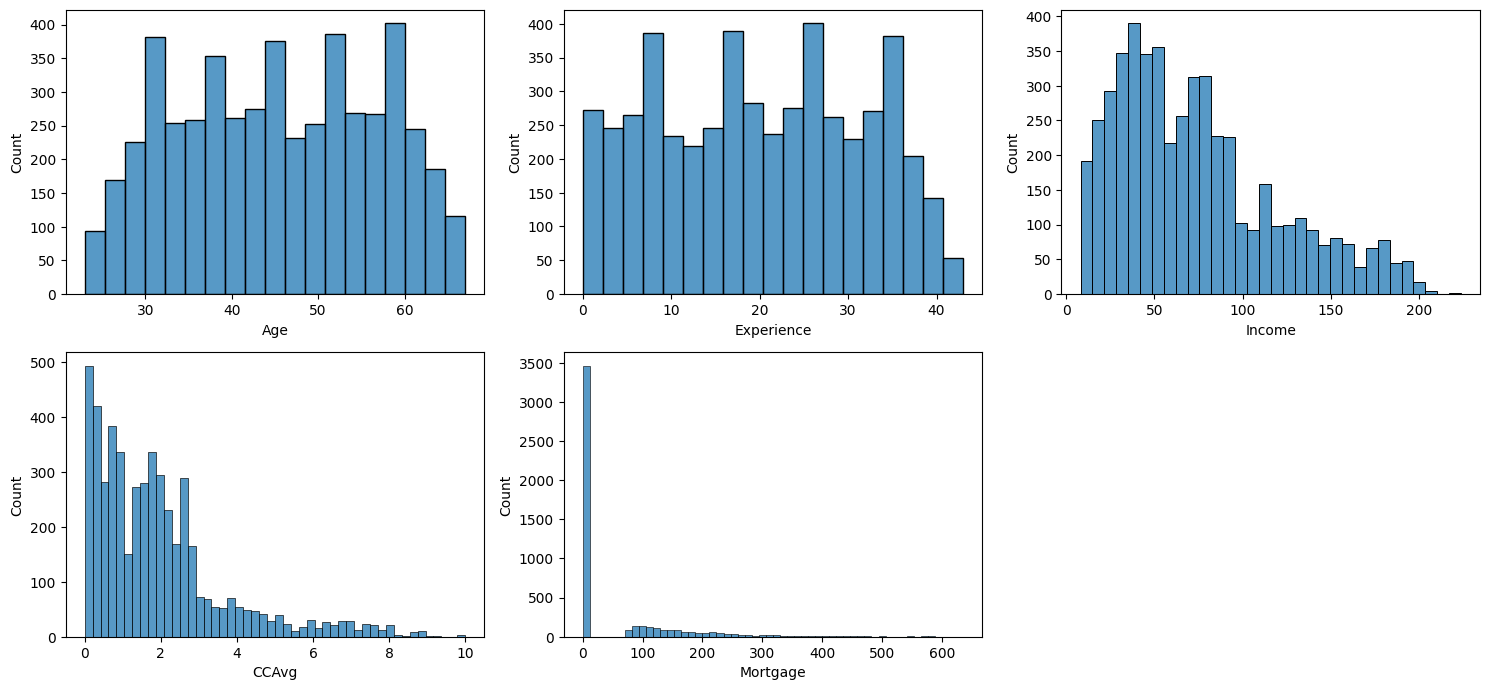

In [ ]:
# defining the figure size
plt.figure(figsize=(15, 10))

# defining the list of numerical features to plot
num_features = ['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage']

# plotting the histogram for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.histplot(data=data, x=feature)    # plot the histogram

plt.tight_layout();   # to add spacing between plots

- **Income** and **CCAvg** exhibit a right-skewed distribution.

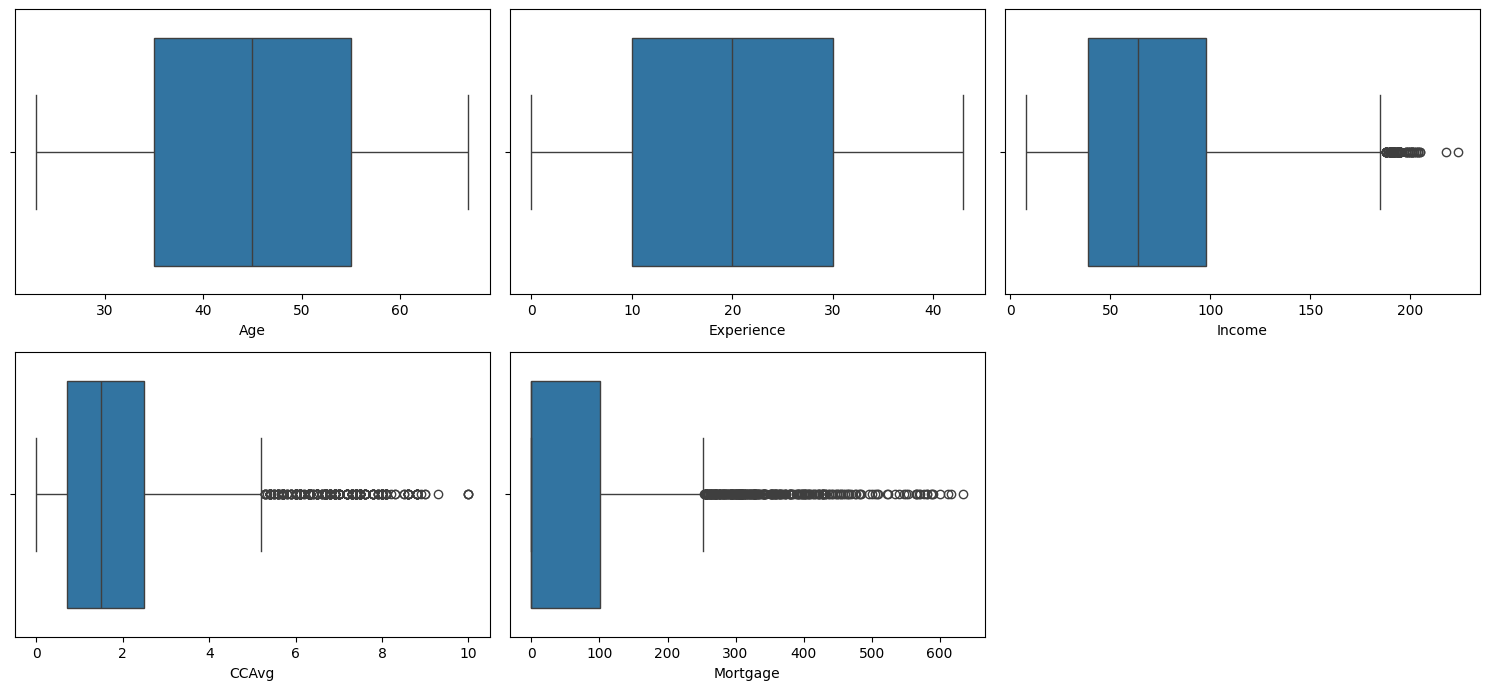

In [ ]:
# defining the figure size
plt.figure(figsize=(15, 10))

# plotting the boxplot for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.boxplot(data=data, x=feature)    # plot the histogram

plt.tight_layout();    # to add spacing between plots

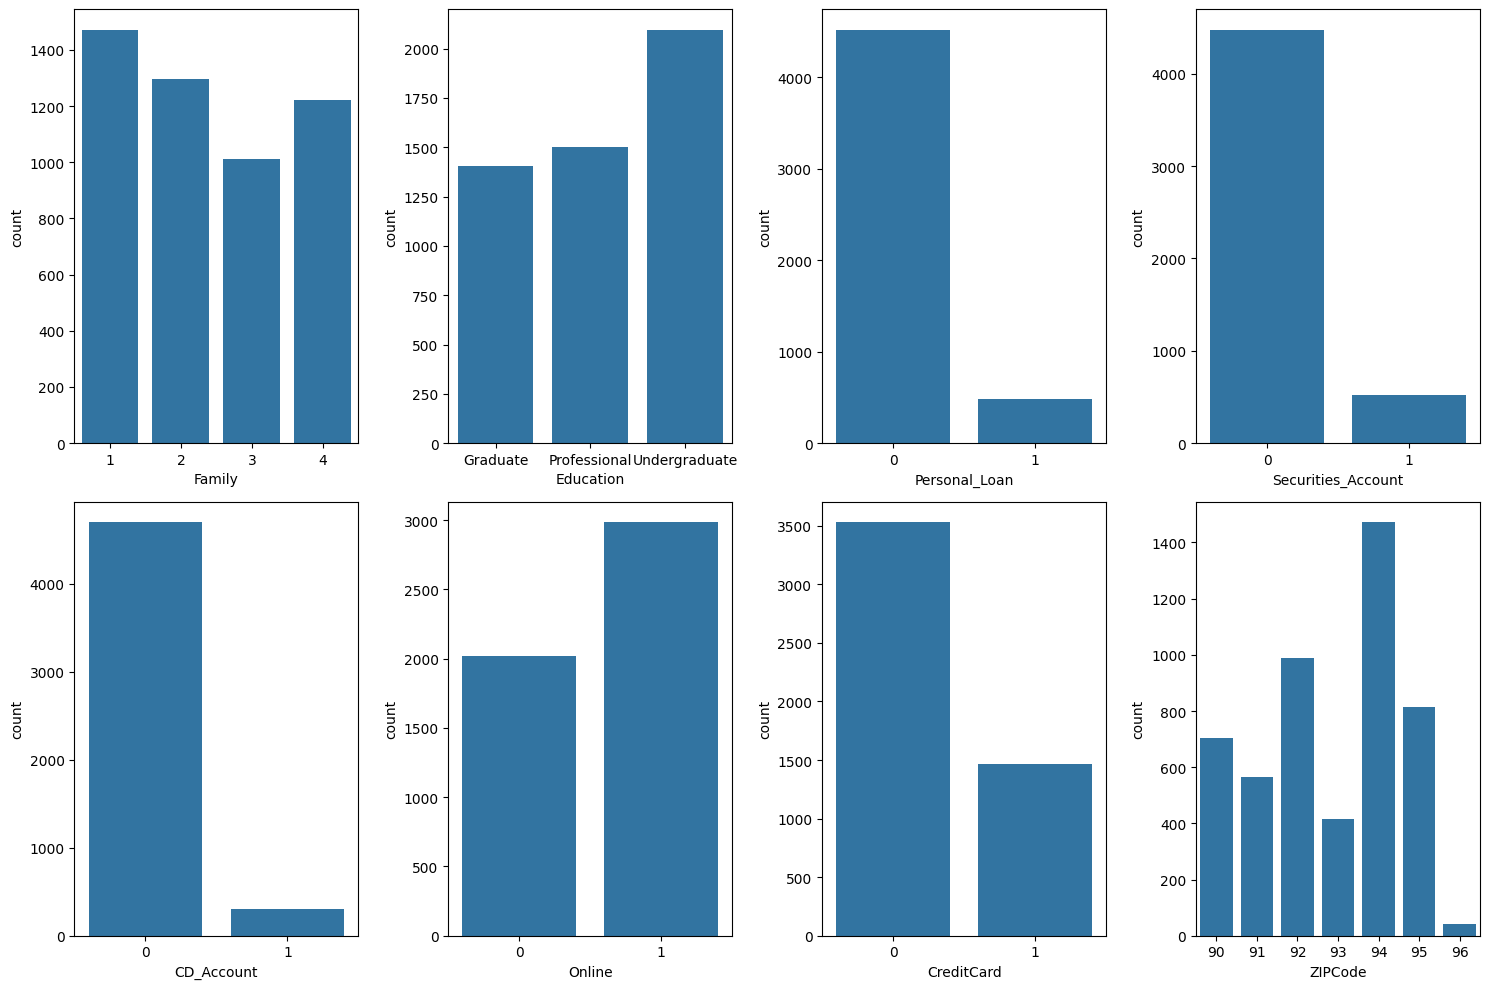

In [ ]:
# defining the figure size
plt.figure(figsize=(15, 10))

# defining the list of numerical features to plot
cat_features = ['Family', 'Education', 'Personal_Loan', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard', 'ZIPCode']

# creating the histograms
for i, feature in enumerate(cat_features):
    plt.subplot(2, 4, i+1)    # assign a subplot in the main plot
    sns.countplot(data=data, x=feature)    # plot the histogram

plt.tight_layout()    # to add spacing between plots
plt.show()

- Large number of customer not accept the personal loan offered in the last campaign.
- Around 1500 out of 5000 customer use a credit card issued by any other Bank.

Online
1    59.68
0    40.32
Name: proportion, dtype: float64 



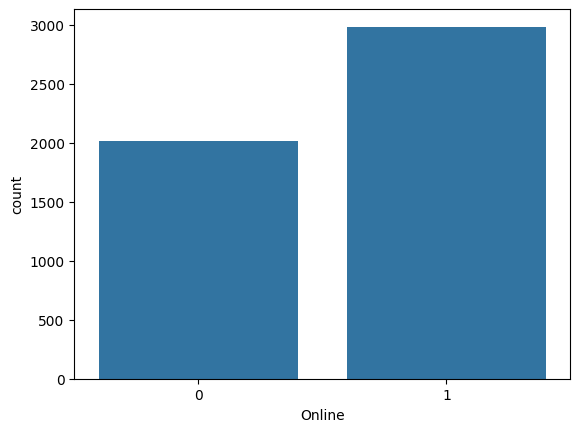

In [ ]:
# checking the distribution of the categories in Approval
print(100*data['Online'].value_counts(normalize=True), '\n')

# plotting the count plot for Approval
sns.countplot(data=data, x='Online');

- Approx 60% Customer use Internet banking facilities.

## **Bivariate Analysis**

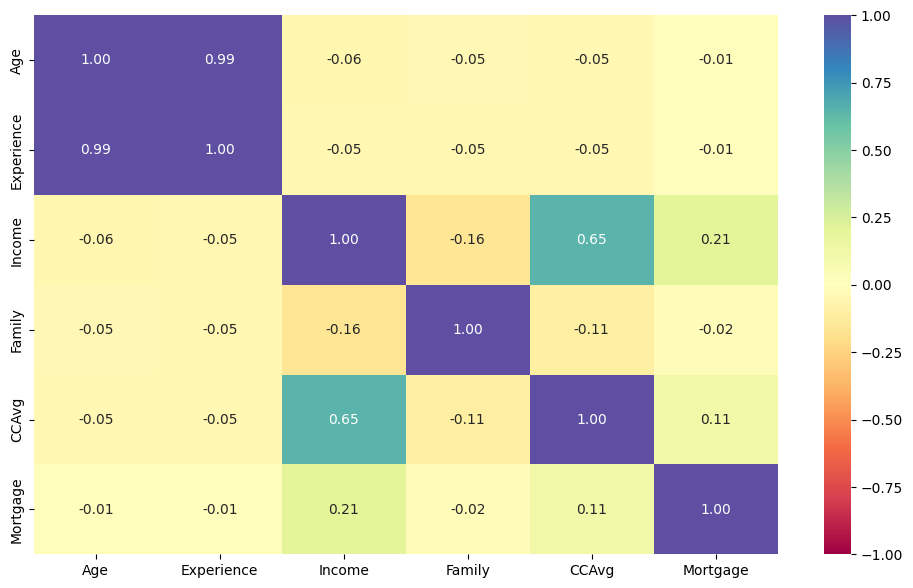

In [ ]:
# defining the figure size
plt.figure(figsize=(12, 7))

# plotting the heatmap for correlation
sns.heatmap(data.corr(numeric_only = True),annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral");
plt.show()

- Age and Experience have a perfect correlation hence one of these variables can be dropped while model building as they will provide the same information to the model.

- Income and CCAvg have a moderate correlation which makes sense as the Income increases the spendings might also increase.

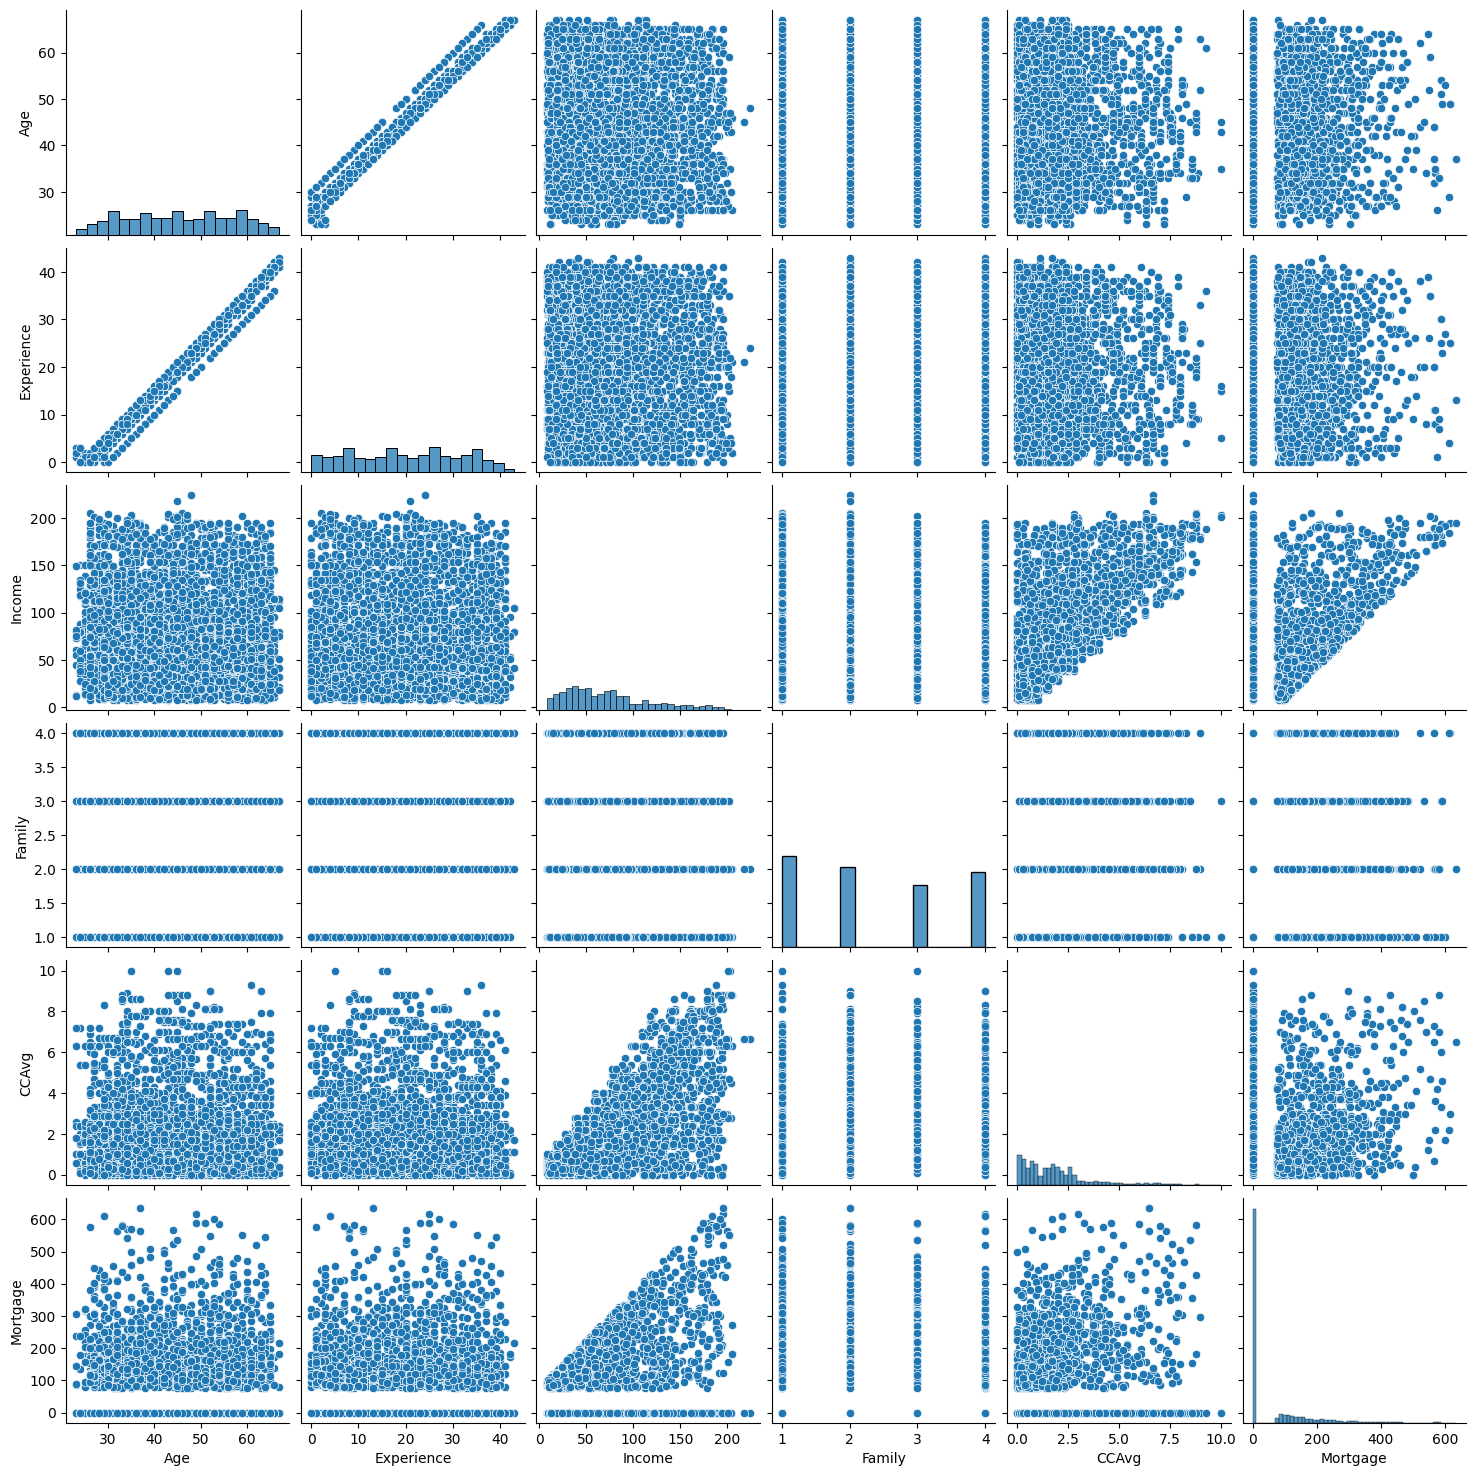

In [ ]:
sns.pairplot(data);

<Figure size 1500x1000 with 0 Axes>

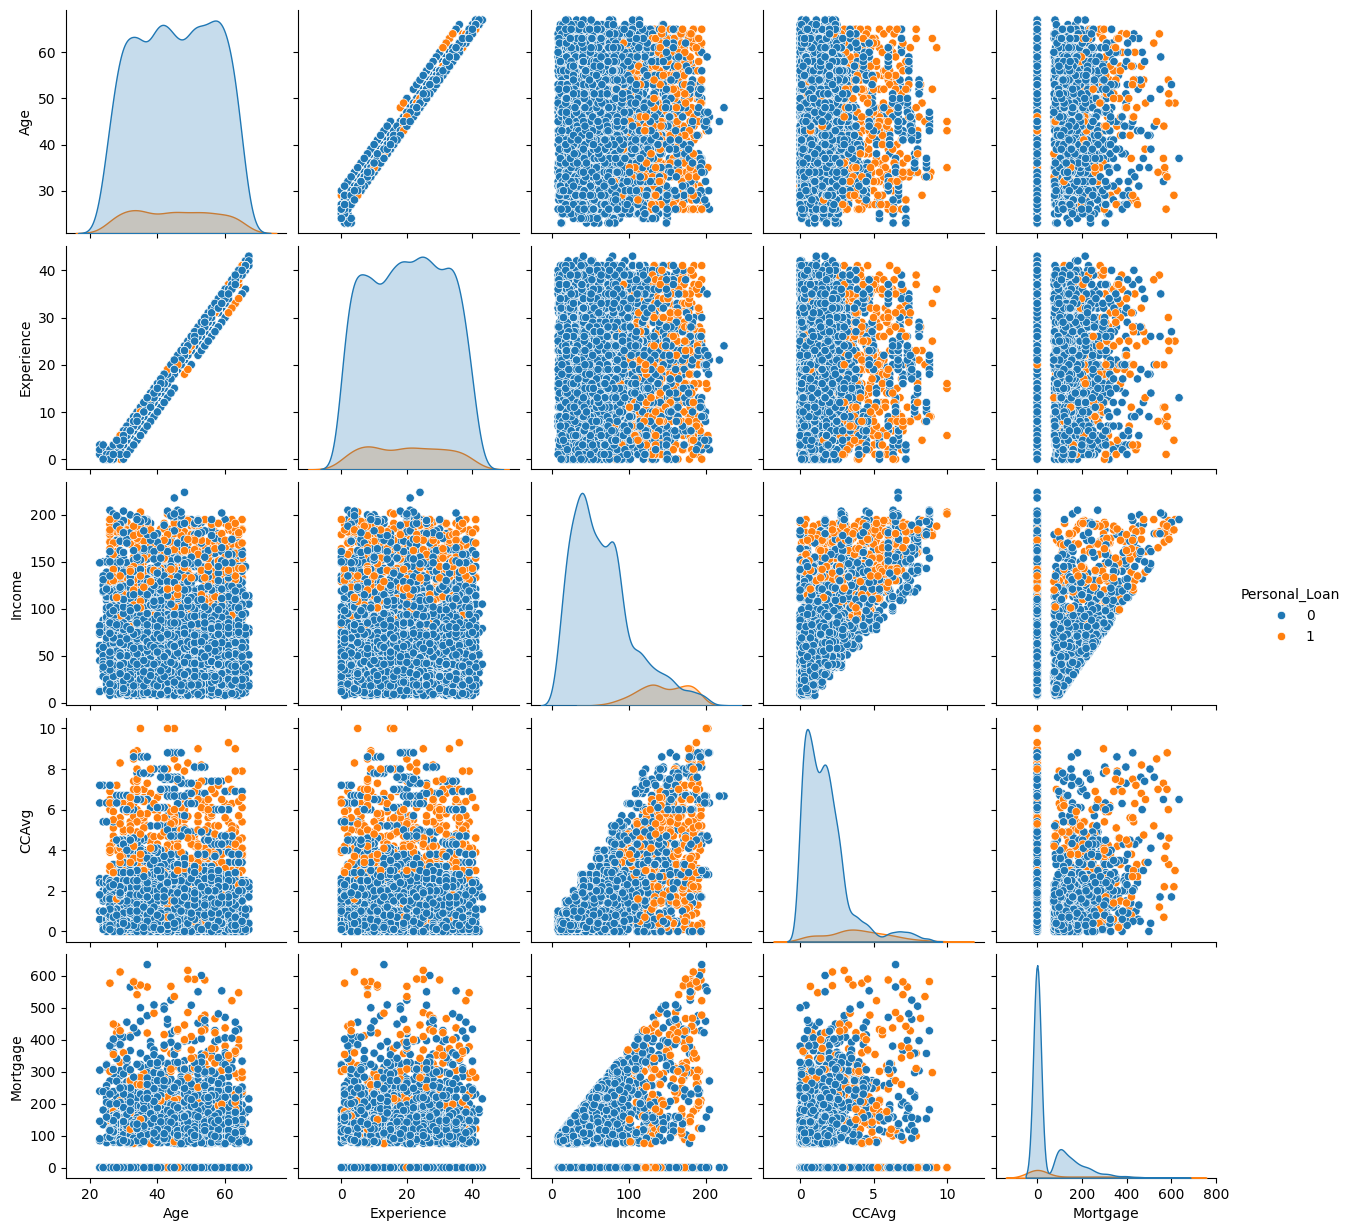

In [ ]:
# Scatter plot matrix
plt.figure(figsize=(15, 10))
sns.pairplot(data, vars=num_features, hue='Personal_Loan', diag_kind='kde');

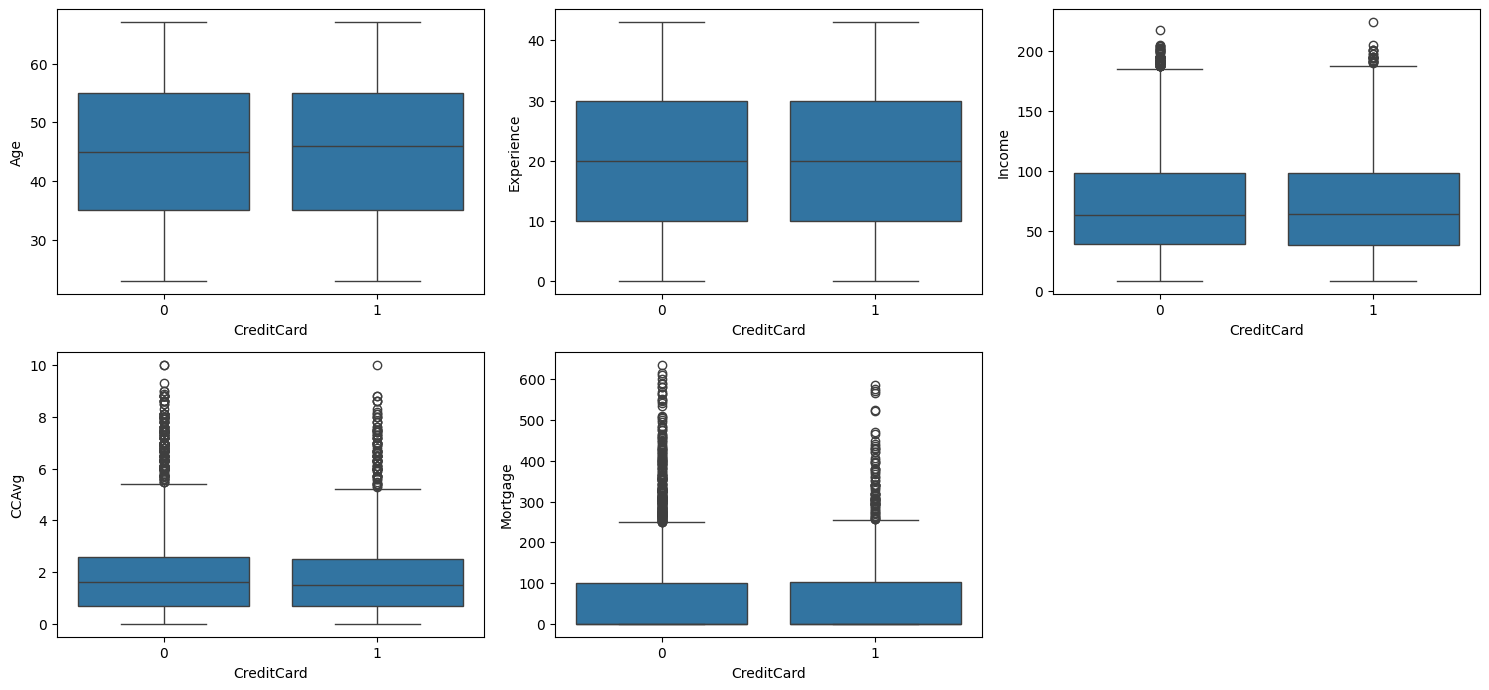

In [ ]:
# defining the figure size
plt.figure(figsize=(15, 10))

# plotting the boxplot for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.boxplot(data=data, x='CreditCard', y=feature)    # plot the histogram

plt.tight_layout();    # to add spacing between plots

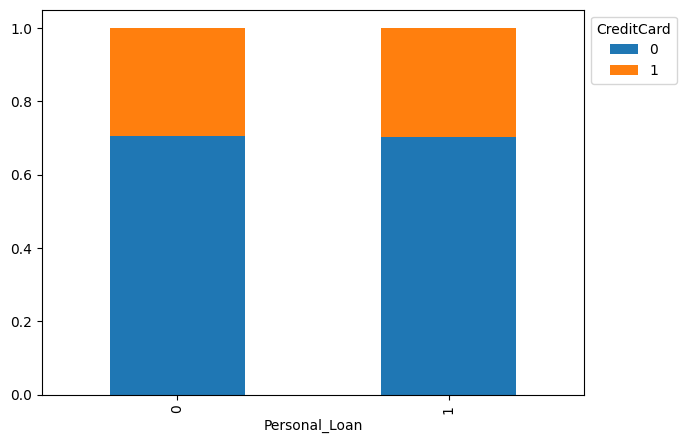

In [ ]:
# creating a crosstab for Approval vs PriorDefault
tab = pd.crosstab(
    data['Personal_Loan'],
    data['CreditCard'],
    normalize='index'    # normalizing by dividing each row by its row total
).sort_values(by=0, ascending=False)    # sorting the resulting crosstab


# Plot the stacked bar chart
tab.plot(kind='bar', stacked=True, figsize=(7, 5))    # creating a stacked bar chart from the normalized crosstab
plt.xlabel('Personal_Loan')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='CreditCard');    # adding a legend for the 'Personal_Loan' column

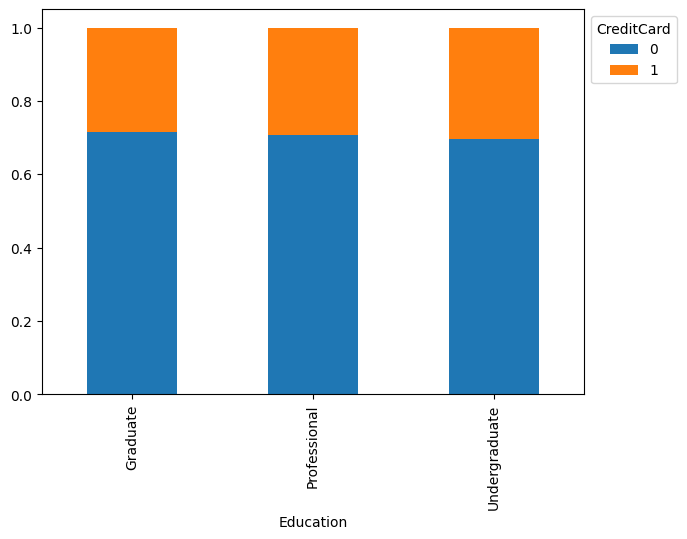

In [ ]:
# creating a crosstab for Approval vs PriorDefault
tab = pd.crosstab(
    data['Education'],
    data['CreditCard'],
    normalize='index'    # normalizing by dividing each row by its row total
).sort_values(by=0, ascending=False)    # sorting the resulting crosstab


# Plot the stacked bar chart
tab.plot(kind='bar', stacked=True, figsize=(7, 5))    # creating a stacked bar chart from the normalized crosstab
plt.xlabel('Education')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='CreditCard');    # adding a legend for the 'Personal_Loan' column

# **Data Preprocessing**

### **Outlier Detection**

In [ ]:
Q1 = data.select_dtypes(include=["float64", "int64"]).quantile(0.25)  # To find the 25th percentile and 75th percentile.
Q3 = data.select_dtypes(include=["float64", "int64"]).quantile(0.75)

IQR = Q3 - Q1  # Inter Quantile Range (75th perentile - 25th percentile)

lower = (Q1 - 1.5 * IQR)  # Finding lower and upper bounds for all values. All values outside these bounds are outliers
upper = (Q3 + 1.5 * IQR)

In [ ]:
(
    (data.select_dtypes(include=["float64", "int64"]) < lower)
    | (data.select_dtypes(include=["float64", "int64"]) > upper)
).sum() / len(data) * 100

,0
Age,0.00
Experience,0.00
Income,1.92
Family,0.00
CCAvg,6.48
Mortgage,5.82


- We will not be treating the outliers as in a real case scenario (in Income, Mortgage value, Average spending on the credit card, etc) and we would want our model to learn the underlying pattern for such customers.

# **Data Preparation for Modeling**

* We have 7 categorical independent variables but 5 of them are binary, so we'll have the same results with them even after creating dummies.
* So we will only make dummies for ZIPCode and Education.

In [ ]:
# dropping Experience as it is perfectly correlated with Age
X = data.drop(["Personal_Loan", "Experience"], axis=1)
Y = data["Personal_Loan"]

X = pd.get_dummies(X, columns=["ZIPCode", "Education"], drop_first=True)

X = X.astype(float)

# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=43)

In [ ]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape,'\n')
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True),'\n')
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (3750, 17)
Shape of test set :  (1250, 17) 

Percentage of classes in training set:
Personal_Loan
0    0.910933
1    0.089067
Name: proportion, dtype: float64 

Percentage of classes in test set:
Personal_Loan
0    0.8832
1    0.1168
Name: proportion, dtype: float64


# **Model Building**

## **Model Evaluation**

  **Model can make wrong predictions as:**

  1. Predicting a customer will take the personal loan, but in reality, the customer will not take the personal loan - Loss of resources
  2. Predicting a customer will not take the personal loan, but in reality, the customer was going to take the personal loan - Loss of opportunity

  **Which case is more important?**
  * Losing a potential customer by predicting that the customer will not be taking the personal loan, but in reality, the customer was going to take the personal loan.

  **How to reduce this loss i.e need to reduce False Negatives?**

  * Bank would want `Recall` to be maximized, the greater the Recall higher the chances of minimizing false negatives. Hence, the focus should be on increasing Recall or minimizing the false negatives.

First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.

- The model_performance_classification_sklearn function will be used to check the model performance of models.
- The confusion_matrix_sklearnfunction will be used to plot confusion matrix.

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

## **Decision Tree (sklearn default)**

In [ ]:
# creating an instance of the decision tree model
model0 = DecisionTreeClassifier(random_state=43)    # random_state sets a seed value and enables reproducibility

# fitting the model to the training data
model0.fit(X_train, y_train)

DecisionTreeClassifier(random_state=43)

### **Checking model performance on training data**

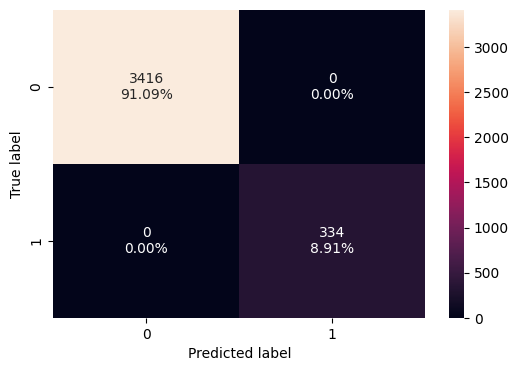

In [ ]:
confusion_matrix_sklearn(model0, X_train, y_train)

In [ ]:
decision_tree_perf_train = model_performance_classification_sklearn(
    model0, X_train, y_train
)
decision_tree_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


* 0 errors on the training set, each sample has been classified correctly.
* Model has performed very well on training set.
* As we know a decision tree will continue to grow and classify each data point correctly if no restrictions are applied as the trees will learn all the patterns in the training set.

### **Visualizing the Decision Tree**

In [ ]:
feature_names = list(X_train.columns)
print(feature_names)

['Age', 'Income', 'Family', 'CCAvg', 'Mortgage', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard', 'ZIPCode_91', 'ZIPCode_92', 'ZIPCode_93', 'ZIPCode_94', 'ZIPCode_95', 'ZIPCode_96', 'Education_Professional', 'Education_Undergraduate']


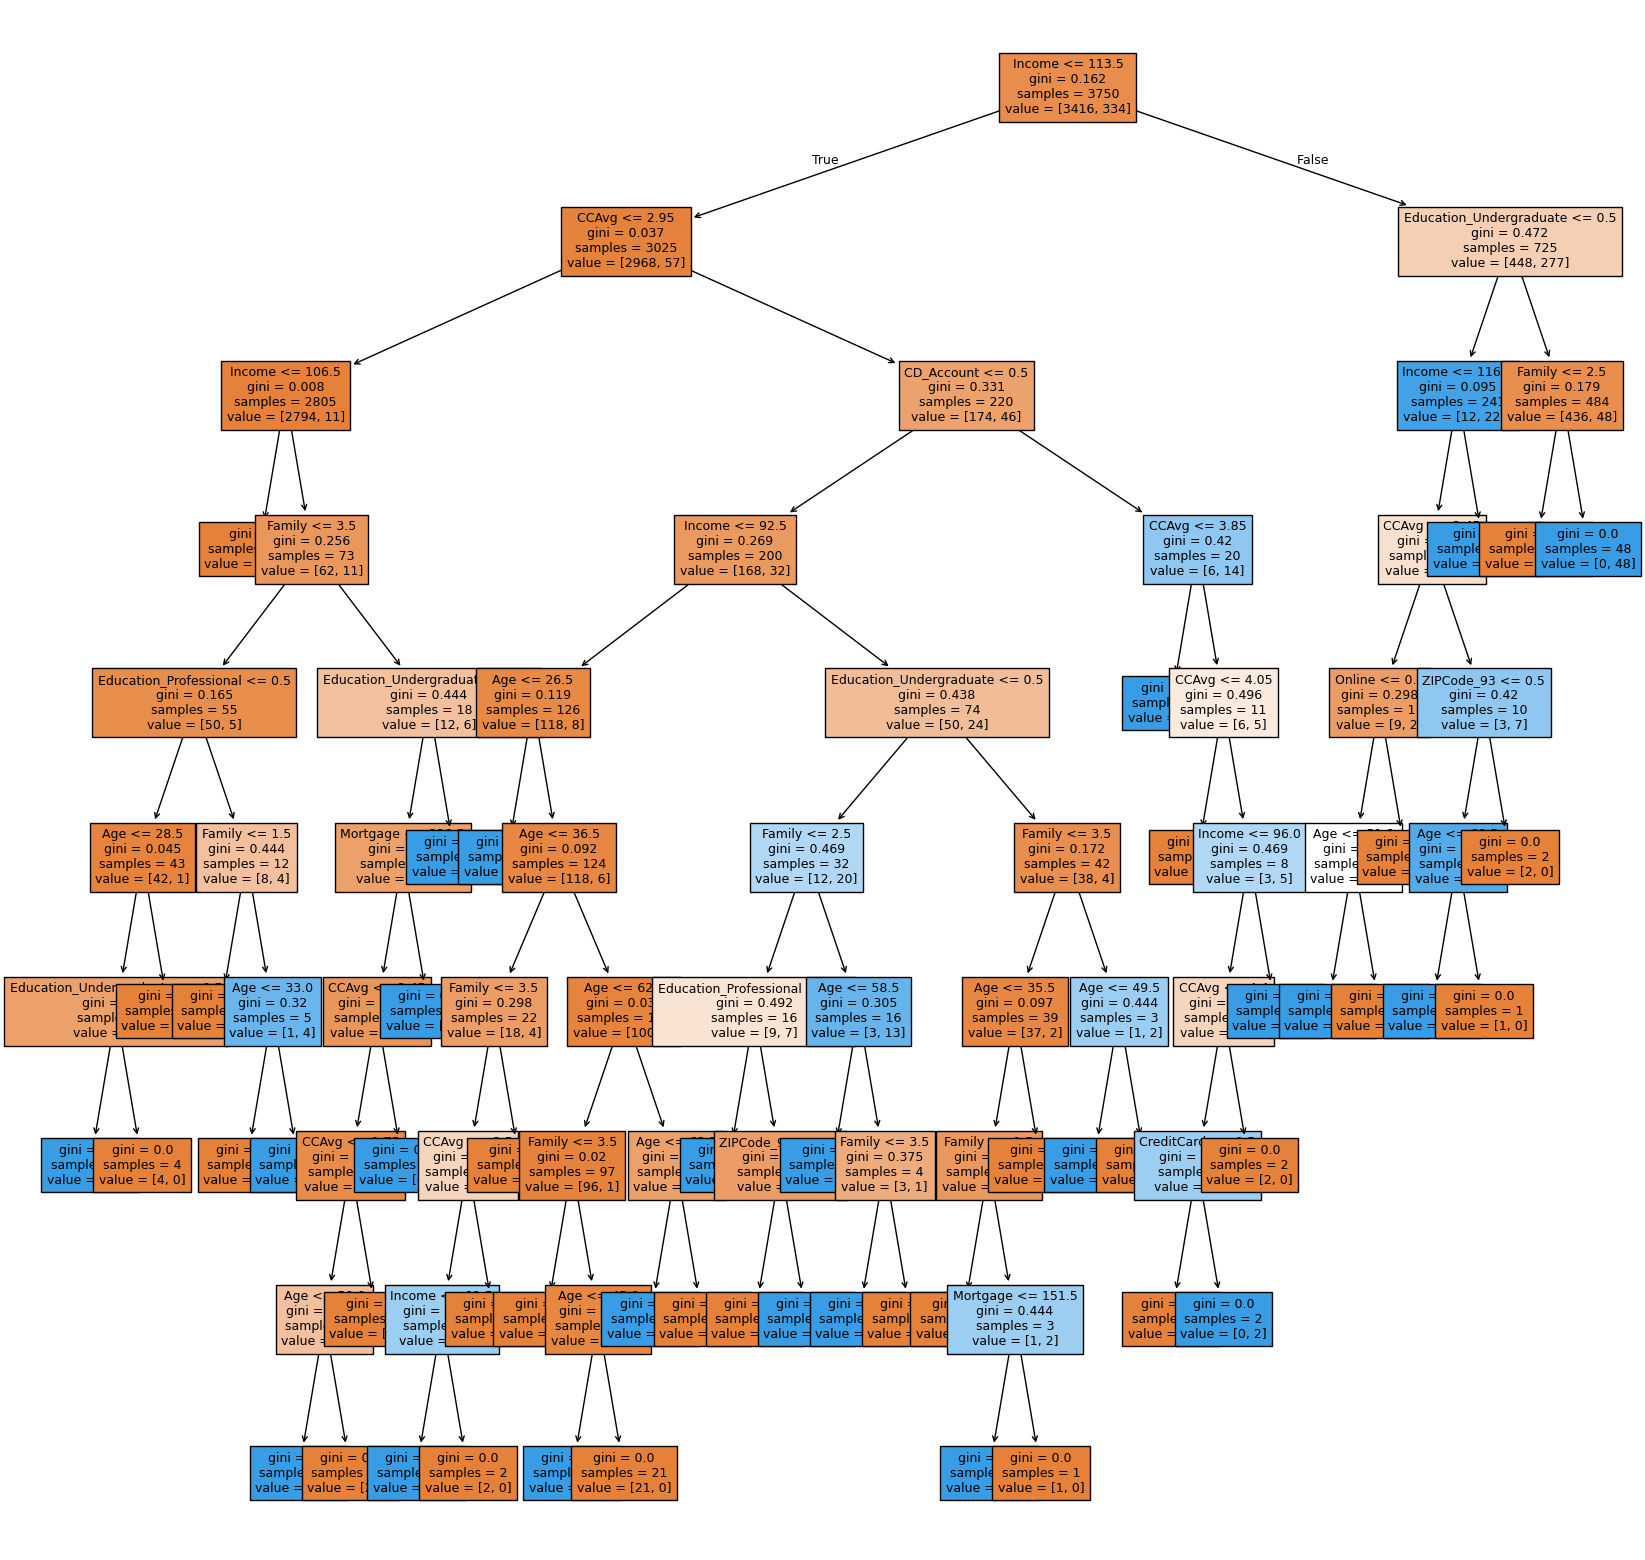

In [ ]:
# set the figure size for the plot
plt.figure(figsize=(20, 20))

# plotting the decision tree
out = tree.plot_tree(
    model0,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

- We can observe that this is a very complex tree.

In [ ]:
# printing a text report showing the rules of a decision tree
print(
    tree.export_text(
        model0,    # specify the model
        feature_names=feature_names,    # specify the feature names
        show_weights=True    # specify whether or not to show the weights associated with the model
    )
)

|--- Income <= 113.50
|   |--- CCAvg <= 2.95
|   |   |--- Income <= 106.50
|   |   |   |--- weights: [2732.00, 0.00] class: 0
|   |   |--- Income >  106.50
|   |   |   |--- Family <= 3.50
|   |   |   |   |--- Education_Professional <= 0.50
|   |   |   |   |   |--- Age <= 28.50
|   |   |   |   |   |   |--- Education_Undergraduate <= 0.50
|   |   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |   |--- Education_Undergraduate >  0.50
|   |   |   |   |   |   |   |--- weights: [4.00, 0.00] class: 0
|   |   |   |   |   |--- Age >  28.50
|   |   |   |   |   |   |--- weights: [38.00, 0.00] class: 0
|   |   |   |   |--- Education_Professional >  0.50
|   |   |   |   |   |--- Family <= 1.50
|   |   |   |   |   |   |--- weights: [7.00, 0.00] class: 0
|   |   |   |   |   |--- Family >  1.50
|   |   |   |   |   |   |--- Age <= 33.00
|   |   |   |   |   |   |   |--- weights: [1.00, 0.00] class: 0
|   |   |   |   |   |   |--- Age >  33.00
|   |   |   |   |   |   |   |--- 

In [ ]:
# importance of features in the tree building
print(
    pd.DataFrame(
        model0.feature_importances_, columns=["Imp"], index=X_train.columns
    ).sort_values(by="Imp", ascending=False)
)

                              Imp
Education_Undergraduate  0.407629
Income                   0.296508
Family                   0.166858
CCAvg                    0.049191
Age                      0.033728
CD_Account               0.017426
Education_Professional   0.010528
ZIPCode_94               0.005378
Mortgage                 0.004445
ZIPCode_93               0.004026
CreditCard               0.002191
Online                   0.002092
Securities_Account       0.000000
ZIPCode_91               0.000000
ZIPCode_92               0.000000
ZIPCode_96               0.000000
ZIPCode_95               0.000000


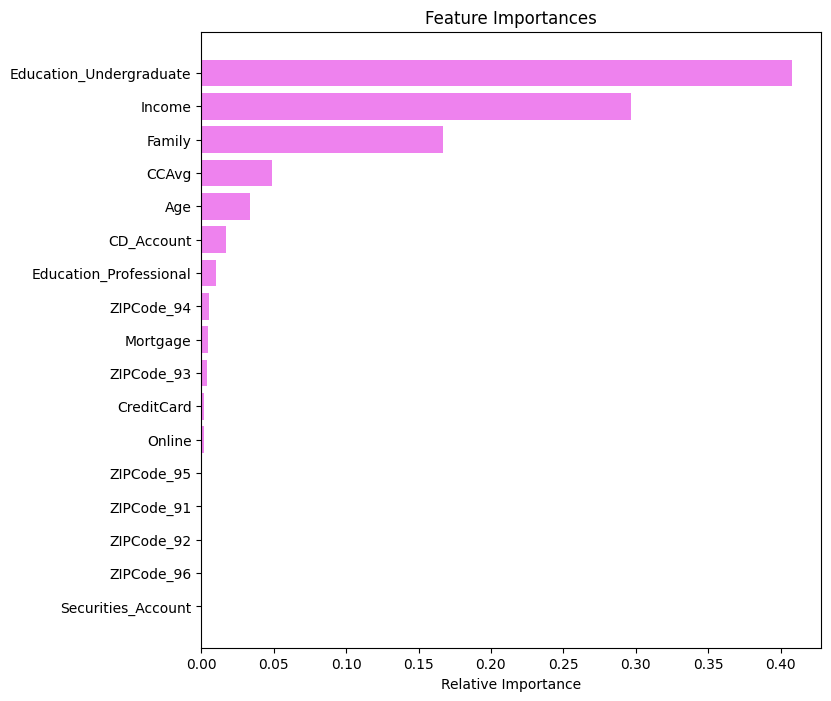

In [ ]:
importances = model0.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

* Education Undergraduated is the most important feature followed by income, family and CCAvg.
* The tree above is very complex and difficult to interpret.
* Let's prune the tree to see if we can reduce the complexity.

### **Checking model performance on test data**

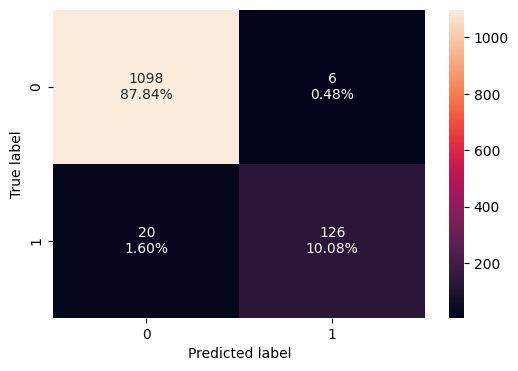

In [ ]:
confusion_matrix_sklearn(model0, X_test, y_test)

In [ ]:
decision_tree_perf_test = model_performance_classification_sklearn(
    model0, X_test, y_test
)
decision_tree_perf_test

,Accuracy,Recall,Precision,F1
0,0.9792,0.863014,0.954545,0.906475


## **Decision Tree (Pre-pruning)**

In [ ]:
# Define the parameters of the tree to iterate over
max_depth_values = np.arange(2, 7, 2)
max_leaf_nodes_values = [50, 75, 150, 250]
min_samples_split_values = [10, 30, 50, 70]


# Initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = float('inf')
best_test_score = 0.0

# Iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # Initialize the tree with the current set of parameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                class_weight='balanced',
                random_state=43
            )

            # Fit the model to the training data
            estimator.fit(X_train, y_train)

            # Make predictions on the training and test sets
            y_train_pred = estimator.predict(X_train)
            y_test_pred = estimator.predict(X_test)

            # Calculate recall scores for training and test sets
            train_recall_score = recall_score(y_train, y_train_pred)
            test_recall_score = recall_score(y_test, y_test_pred)

            # Calculate the absolute difference between training and test recall scores
            score_diff = abs(train_recall_score - test_recall_score)

            # Update the best estimator and best score if the current one has a smaller score difference
            if (score_diff < best_score_diff) & (test_recall_score > best_test_score):
                best_score_diff = score_diff
                best_test_score = test_recall_score
                best_estimator = estimator

# creating an instance of the best model
model1 = best_estimator

# Print the best parameters
print("Best parameters found:")
print(f"Max depth: {best_estimator.max_depth}")
print(f"Max leaf nodes: {best_estimator.max_leaf_nodes}")
print(f"Min samples split: {best_estimator.min_samples_split}")
print(f"Best test recall score: {best_test_score}")

Best parameters found:
Max depth: 2
Max leaf nodes: 50
Min samples split: 10
Best test recall score: 1.0


In [ ]:
decision_tree_tune_perf_train = model_performance_classification_sklearn(
    model1, X_train, y_train
)
decision_tree_tune_perf_train

,Accuracy,Recall,Precision,F1
0,0.784267,1.0,0.292213,0.452268


### **Checking model performance on training data**

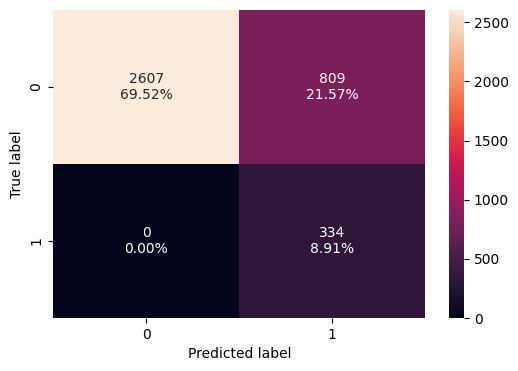

In [ ]:
confusion_matrix_sklearn(model1, X_train, y_train)

### **Visualizing the Decision Tree**

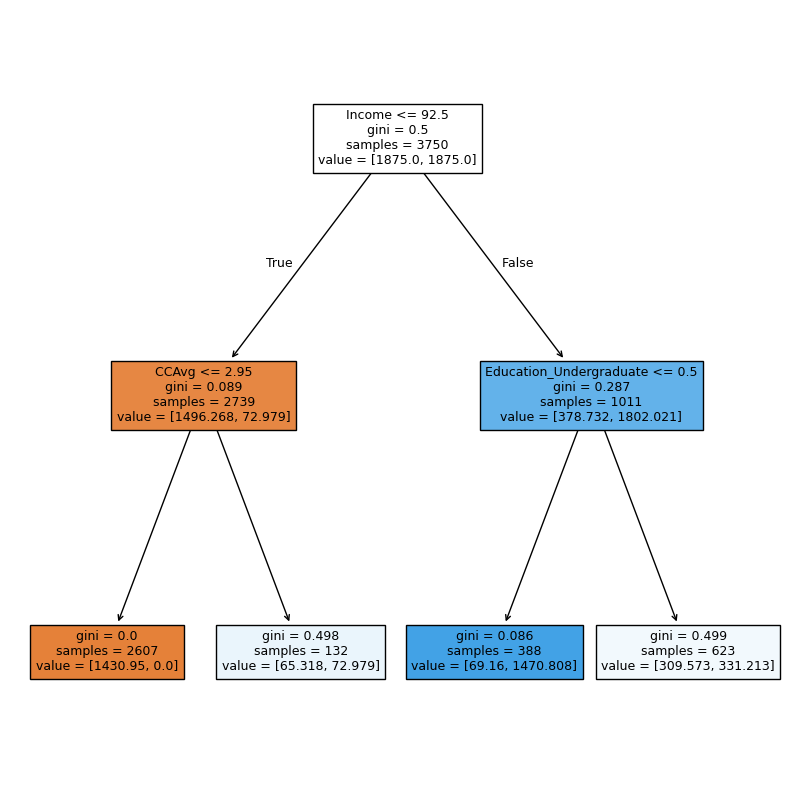

In [ ]:
plt.figure(figsize=(10, 10))
out = tree.plot_tree(
    model1,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [ ]:
# Text report showing the rules of a decision tree -

print(tree.export_text(model1, feature_names=feature_names, show_weights=True))

|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1430.95, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- weights: [65.32, 72.98] class: 1
|--- Income >  92.50
|   |--- Education_Undergraduate <= 0.50
|   |   |--- weights: [69.16, 1470.81] class: 1
|   |--- Education_Undergraduate >  0.50
|   |   |--- weights: [309.57, 331.21] class: 1



In [ ]:
# importance of features in the tree building

print(
    pd.DataFrame(
        model1.feature_importances_, columns=["Imp"], index=X_train.columns
    ).sort_values(by="Imp", ascending=False)
)

                              Imp
Income                   0.819773
Education_Undergraduate  0.128353
CCAvg                    0.051874
Age                      0.000000
Family                   0.000000
Securities_Account       0.000000
CD_Account               0.000000
Online                   0.000000
Mortgage                 0.000000
CreditCard               0.000000
ZIPCode_91               0.000000
ZIPCode_93               0.000000
ZIPCode_92               0.000000
ZIPCode_94               0.000000
ZIPCode_95               0.000000
ZIPCode_96               0.000000
Education_Professional   0.000000


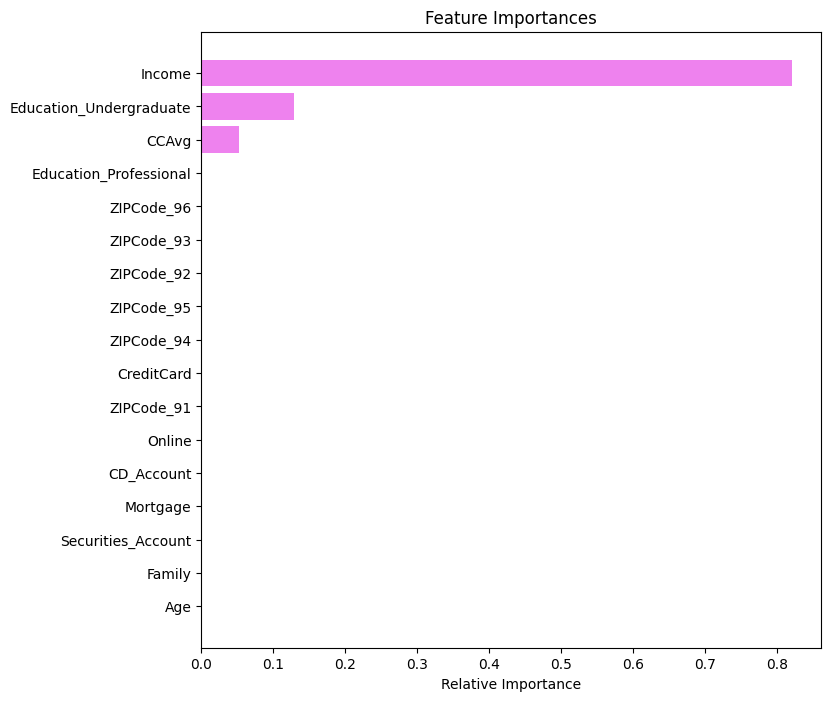

In [ ]:
importances = model1.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

### **Checking model performance on test data**

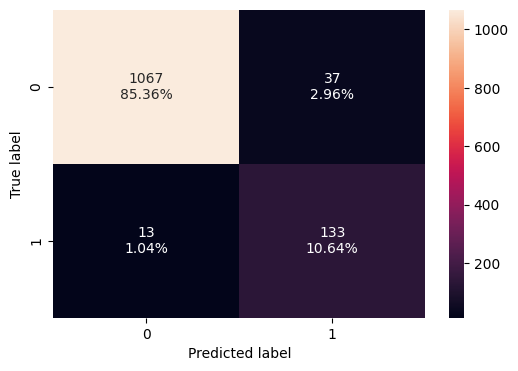

In [ ]:
confusion_matrix_sklearn(estimator, X_test, y_test)

In [ ]:
decision_tree_tune_perf_test = model_performance_classification_sklearn(
    estimator, X_test, y_test
)
decision_tree_tune_perf_test

,Accuracy,Recall,Precision,F1
0,0.96,0.910959,0.782353,0.841772


## **Decision Tree (Post-pruning)**

In [ ]:
# Create an instance of the decision tree model
clf = DecisionTreeClassifier(random_state=43)

# Compute the cost complexity pruning path for the model using the training data
path = clf.cost_complexity_pruning_path(X_train, y_train)

# Extract the array of effective alphas from the pruning path & total impurities at each alpha along the pruning path
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [ ]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000,0.000000
1,0.000246,0.000492
2,0.000260,0.001013
3,0.000261,0.002059
4,0.000320,0.002699
5,0.000337,0.003711
6,0.000356,0.004067
7,0.000360,0.004427
8,0.000394,0.005214
9,0.000400,0.005614


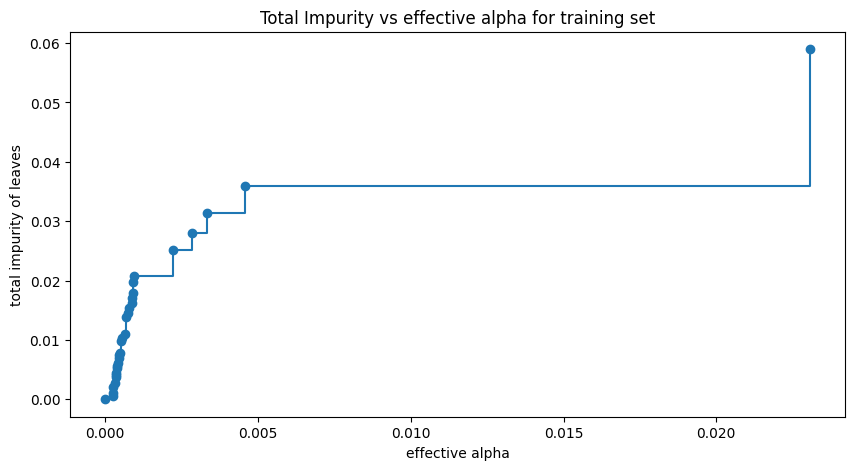

In [ ]:
# Create a figure
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the total impurities versus effective alphas, excluding the last value,
# using markers at each data point and connecting them with steps
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")

# Set the x-axis label
ax.set_xlabel("effective alpha")

# Set the y-axis label
ax.set_ylabel("total impurity of leaves")

# Set the title of the plot
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

Next, we train a decision tree using effective alphas. The last value
in ``ccp_alphas`` is the alpha value that prunes the whole tree,
leaving the tree, ``clfs[-1]``, with one node.

In [ ]:
# Initialize an empty list to store the decision tree classifiers
clfs = []

# Iterate over each ccp_alpha value extracted from cost complexity pruning path
for ccp_alpha in ccp_alphas:
    # Create an instance of the DecisionTreeClassifier
    clf = DecisionTreeClassifier(random_state=43, ccp_alpha=ccp_alpha)

    # Fit the classifier to the training data
    clf.fit(X_train, y_train)

    # Append the trained classifier to the list
    clfs.append(clf)

# Print the number of nodes in the last tree along with its ccp_alpha value
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.05164896636588442


- Moving ahead, we remove the last element in
``clfs`` and ``ccp_alphas`` as it corresponds to a trivial tree with only one
node.

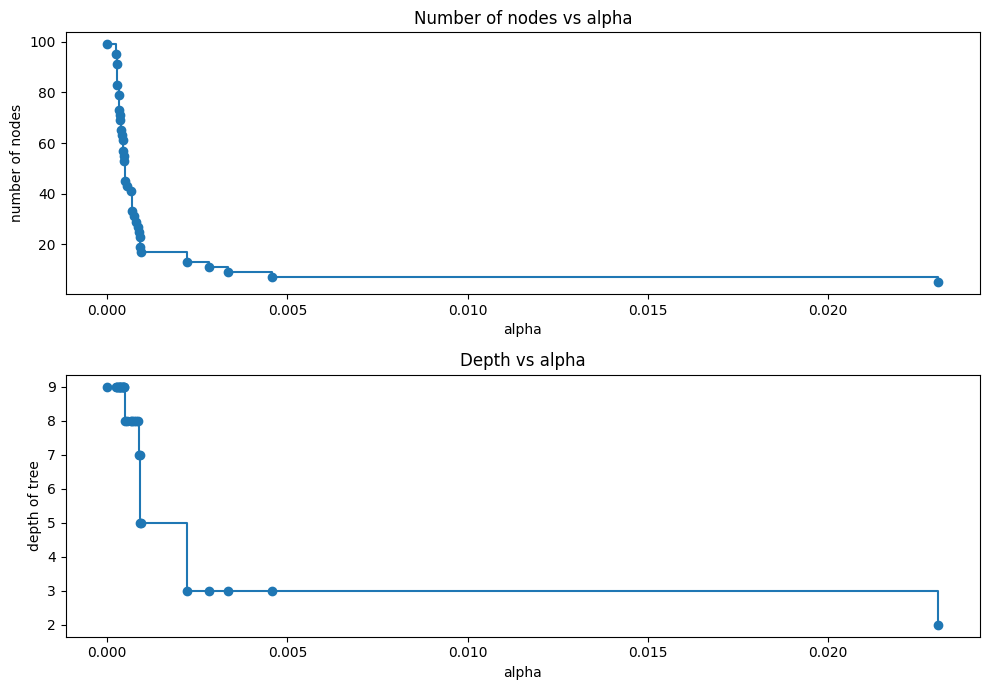

In [ ]:
# Remove the last classifier and corresponding ccp_alpha value from the lists
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

# Extract the number of nodes in each tree classifier
node_counts = [clf.tree_.node_count for clf in clfs]

# Extract the maximum depth of each tree classifier
depth = [clf.tree_.max_depth for clf in clfs]

# Create a figure and a set of subplots
fig, ax = plt.subplots(2, 1, figsize=(10, 7))

# Plot the number of nodes versus ccp_alphas on the first subplot
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")

# Plot the depth of tree versus ccp_alphas on the second subplot
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")

# Adjust the layout of the subplots to avoid overlap
fig.tight_layout()

### **Recall vs alpha for training and testing sets**

In [ ]:
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train)
    recall_train.append(values_train)

recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test)
    recall_test.append(values_test)

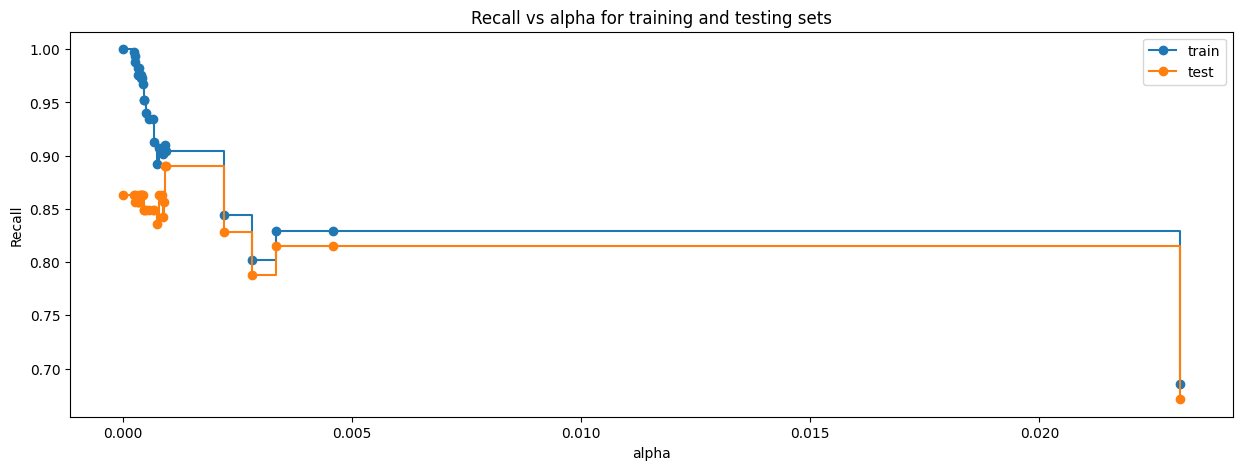

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [ ]:
# creating the model where we get highest Recall Score
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
model2 = best_model
print(best_model)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0009136363636363636),
                       random_state=43)


* Post-pruning using ccp alpha returns the same model as the initial model (Tree with no pruning).
* As post pruning model is the same as the initial decision tree mode, the performance and feature importance will also be the same.

In [ ]:
estimator_2 = DecisionTreeClassifier(
    ccp_alpha=ccp_alpha, class_weight='balanced', random_state=43         ## Complete the code by adding the correct ccp_alpha value
)
estimator_2.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.05164896636588442),
                       class_weight='balanced', random_state=43)

### **Checking performance on training data**

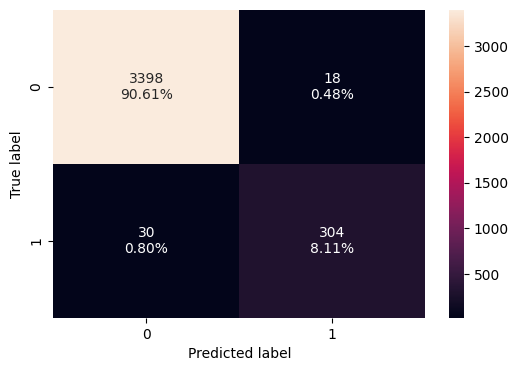

In [ ]:
confusion_matrix_sklearn(model2, X_train, y_train)

In [ ]:
decision_tree_tune_post_train = model_performance_classification_sklearn(model2, X_train, y_train) ## Complete the code to check performance on train data
decision_tree_tune_post_train

,Accuracy,Recall,Precision,F1
0,0.9872,0.91018,0.944099,0.926829


### **Visualizing the Decision Tree**

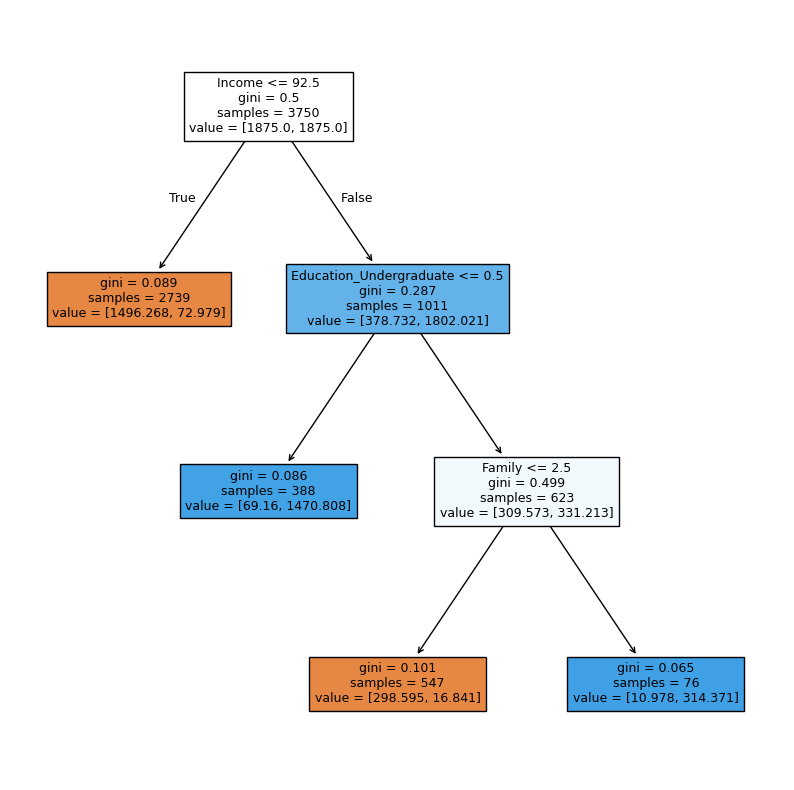

In [ ]:
plt.figure(figsize=(10, 10))
out = tree.plot_tree(
    estimator_2,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [ ]:
# Text report showing the rules of a decision tree -

print(tree.export_text(estimator_2, feature_names=feature_names, show_weights=True))

|--- Income <= 92.50
|   |--- weights: [1496.27, 72.98] class: 0
|--- Income >  92.50
|   |--- Education_Undergraduate <= 0.50
|   |   |--- weights: [69.16, 1470.81] class: 1
|   |--- Education_Undergraduate >  0.50
|   |   |--- Family <= 2.50
|   |   |   |--- weights: [298.59, 16.84] class: 0
|   |   |--- Family >  2.50
|   |   |   |--- weights: [10.98, 314.37] class: 1



In [ ]:
# importance of features in the tree building

print(
    pd.DataFrame(
        estimator_2.feature_importances_, columns=["Imp"], index=X_train.columns
    ).sort_values(by="Imp", ascending=False)
)

                              Imp
Income                   0.715786
Family                   0.172143
Education_Undergraduate  0.112072
Age                      0.000000
CCAvg                    0.000000
Securities_Account       0.000000
CD_Account               0.000000
Online                   0.000000
Mortgage                 0.000000
CreditCard               0.000000
ZIPCode_91               0.000000
ZIPCode_93               0.000000
ZIPCode_92               0.000000
ZIPCode_94               0.000000
ZIPCode_95               0.000000
ZIPCode_96               0.000000
Education_Professional   0.000000


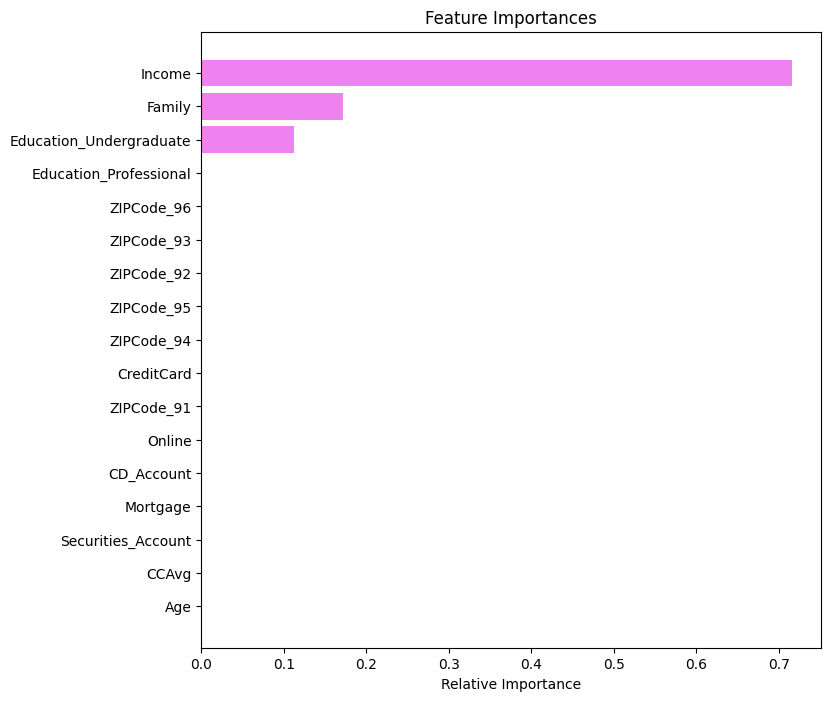

In [ ]:
importances = estimator_2.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

### **Checking performance on test data**

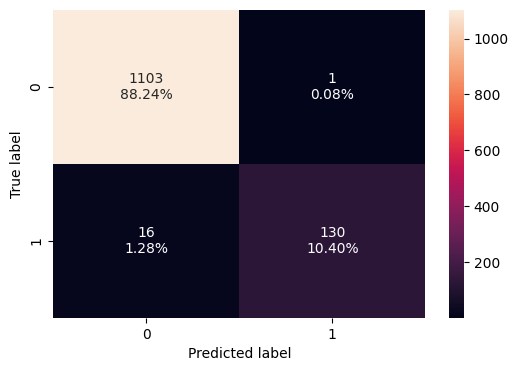

In [ ]:
confusion_matrix_sklearn(model2, X_test, y_test)  # Complete the code to get the confusion matrix on test data

In [ ]:
# Complete the code to get the model performance on test data
decision_tree_tune_post_test = model_performance_classification_sklearn(model2, X_test, y_test)
decision_tree_tune_post_test

,Accuracy,Recall,Precision,F1
0,0.9864,0.890411,0.992366,0.938628


# **Model Performance Comparison and Final Model Selection**

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [decision_tree_perf_train.T, decision_tree_tune_perf_train.T, decision_tree_tune_post_train.T], axis=1,
)
models_train_comp_df.columns = ["Decision Tree (sklearn default)", "Decision Tree (Pre-Pruning)", "Decision Tree (Post-Pruning)"]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.0,0.784267,0.987200
Recall,1.0,1.000000,0.910180
Precision,1.0,0.292213,0.944099
F1,1.0,0.452268,0.926829


In [ ]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [decision_tree_perf_test.T, decision_tree_tune_perf_test.T, decision_tree_tune_post_test.T], axis=1,
)
models_test_comp_df.columns = ["Decision Tree (sklearn default)", "Decision Tree (Pre-Pruning)", "Decision Tree (Post-Pruning)"]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.979200,0.960000,0.986400
Recall,0.863014,0.910959,0.890411
Precision,0.954545,0.782353,0.992366
F1,0.906475,0.841772,0.938628


**Conclusion**
* Overall, the Decision Tree (Pre-Pruning) performs perfectly on the training set with a recall score of 100%, but its recall score on the test set is around 92%, indicating some overfitting to the training data.
* Looking at important variables based on Feature importance in Decision trees
    * Income, CCAvg, CD_Account, Family, Education are important features for decision making

# **Actionable Insights and Business Recommendations**

* We have been able to build a predictive model:

  a) that the bank can deploy to identify customers who will be interested in taking a personal loan.

  b) that the bank can use to find the key factors that will have an impact on a customer taking a personal loan or not.

* Factors that have an impact on Personal_Loan: Income, Family, Education.

* Higher income customers should be the target customers for the bank - Customers who have income above 116k dollars and a family of more than 2, such customers have higher chances of taking personal loans.

* Higher education higher are the chances to take a loan - Customers who are more educated (education level greater than undergraduate) have a higher chance of taking a personal loan.

* Size of the family has a positive correlation with the personal loan, as the size of the family increases (generally a family size of 3 or more than 3 members) have more chances of a customer taking a personal loan.

* Our analysis showed that ~50% of the customers who have the certificate of deposit with the bank (CD_Account) are the ones that have the requirement of Personal Loan - Bank should target such customers.